# Example-11: Quasiperiodic decomposition

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Define nonlinear map

amplitude = torch.tensor(1.0, dtype=dtype, device=device)

nux = torch.tensor(2.0*numpy.pi*0.38, dtype=dtype, device=device)
nuy = torch.tensor(2.0*numpy.pi*0.41, dtype=dtype, device=device)

cx, sx = nux.cos(), nux.sin()
cy, sy = nuy.cos(), nuy.sin()

@torch.func.vmap
def henon(state:torch.tensor) -> torch.tensor:
    local = torch.clone(state)
    local[0] = cx*state[0] + sx*(amplitude*(state[0]**2 -state[2]**2) + state[1])
    local[1] = cx*(amplitude*(state[0]**2 - state[2]**2) + state[1]) - sx*state[0]
    local[2] = cy*state[2] + sy*(state[3] - 2.0*amplitude*state[0]*state[2])
    local[3] = cy*(state[3] - 2.0*amplitude*state[0]*state[2]) + sy*state[2]
    return local

# Generate test trajectories

state = torch.tensor([[0.00625*i, 1.0E-12, 0.0, 0.0] for i in range(80 + 1)], dtype=dtype, device=device)

qx, px = [], []
qx.append(state[:, 0])
px.append(state[:, 1])

count = 2**12 - 1
for _ in range(count):
    state = henon(state)
    qx.append(state[:, 0])
    px.append(state[:, 1])

qx = torch.stack(qx)
px = torch.stack(px)

In [4]:
# Set window & data

win = Window.from_cosine(2**12, 4.0, dtype=dtype, device=device)
tbt = Data.from_data(win, qx.T)
print(tbt)

Data(81, Window(4096, 'cosine_window', 4.0))


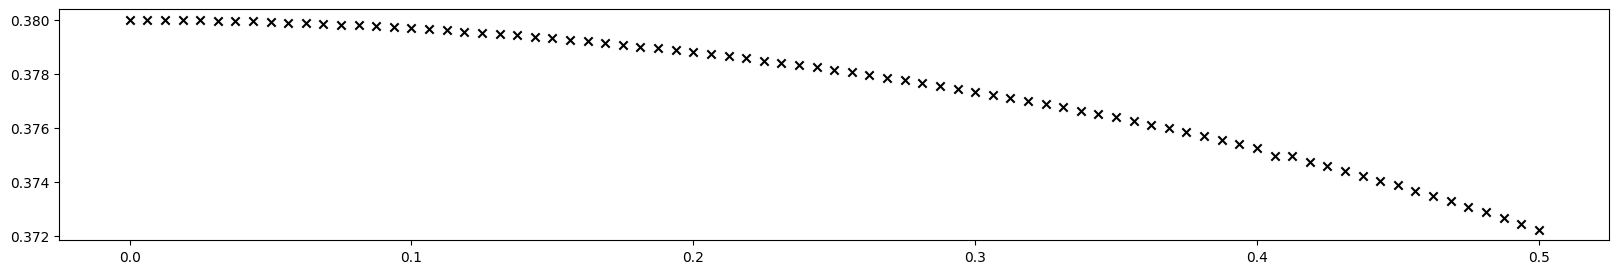

In [5]:
# Estimate main frequency

fre = Frequency(tbt)
fre.data.window_remove_mean()
fre.data.window_apply()
fre('parabola')
fre.data.reset()

# Plot frequency vs initial amplitude

plt.figure(figsize=(20, 3))
plt.scatter(tbt.data[:, 0].cpu().numpy(), fre.frequency.cpu().numpy(), color='black', marker='x')
plt.show()

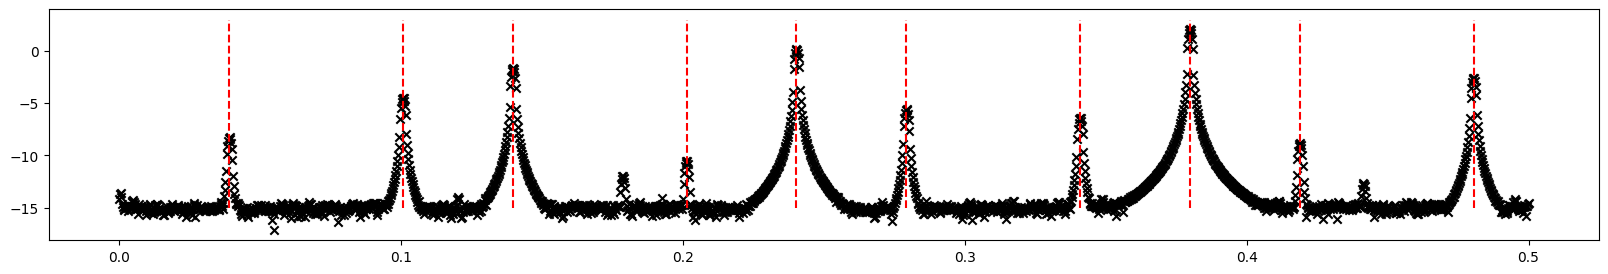

In [6]:
# Each (stable) orbit is an infinite sum of (fast) decaying harmonics of fundamental frequencies
# With these initial conditions, the motion is 2d and only one fundamental frequency is present
# This frequency also corresponds to a frequency with the largest amplitude
# Note, this is not always the case for higher dimensions

# Select an orbit to decompose & plot correponding spectrum
# Several harmonics of fundamental frequency can be seen

index = 10

table = Frequency.harmonics(10, [fre.frequency[index].cpu().item()]).values()

plt.figure(figsize=(20, 3))
plt.scatter(fre.fft_grid.cpu().numpy(), fre.fft_spectrum[index].log10(), color='black', marker='x')
plt.vlines(table, -15.0, 3.0, linestyles='dashed', color='red')
plt.show()

In [7]:
# Estimate parameters for several first harmonics
# Estimate frequency of the largest peak, estimate corresponding parameters using harmonic sums, subtract and cycle

index = 20
limit = 5

signal = torch.clone(qx.T[index])
signal = signal - signal.mean()

table = []

win = Window.from_cosine(2**12, 4.0, dtype=dtype, device=device)

for _ in range(limit):
    tbt = Data.from_data(win, signal.reshape(1, -1))
    fre = Frequency(tbt)
    dec = Decomposition(tbt)
    fre.data.window_remove_mean()
    fre.data.window_apply()
    fre('parabola')
    f = fre.frequency.squeeze()
    parameter, _ = dec.harmonic_sum(f, win.window, tbt.data)
    c, s, *_ = parameter.squeeze()
    table.append(torch.stack([f, c, s]))
    signal -= Data.make_harmonic(len(signal), f, c=c, s=s)

table = torch.stack(table)

In [8]:
# Identify harmonics

order = 100
for key, value in Frequency.identify(order, table[0:1, 0].cpu().numpy().tolist(), table[:, 0].cpu().numpy().tolist()).items():
    print(key, value)

(1,) [0.3795181678866871, 0.3795181678866871, 0.0]
(2,) [0.24096366422662585, 0.2409636642266249, 9.43689570931383e-16]
(3,) [0.13855450366006128, 0.13855450366006306, 1.7763568394002505e-15]
(4,) [0.4819273284532517, 0.4819273284532494, 2.275957200481571e-15]
(5,) [0.10240916056656468, 0.10240916056682584, 2.6115221096745245e-13]


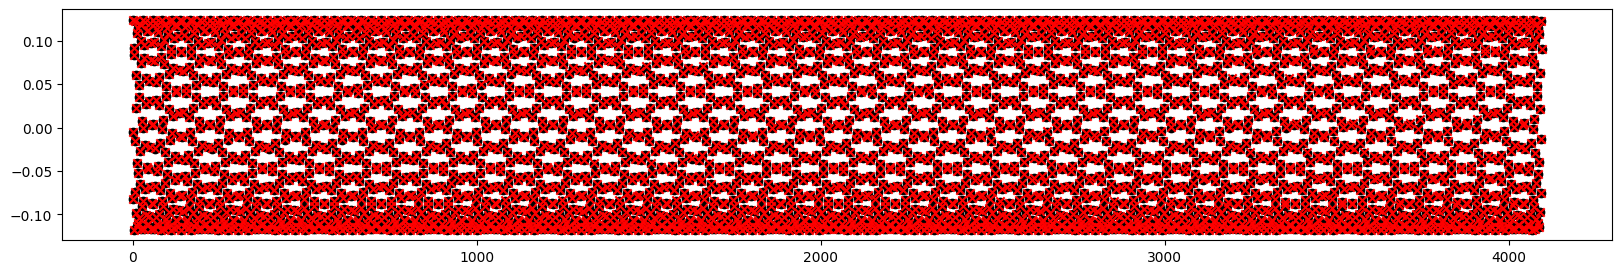

In [9]:
# Reconstruct & plot signal

orbit = torch.zeros_like(signal)
for f, c, s in table:
    orbit += Data.make_harmonic(len(orbit), f, c=c, s=s)

plt.figure(figsize=(20, 3))
plt.scatter(range(2**12), (qx.T[index] - qx.T[index].mean()).cpu().numpy(), color='black', marker='o')
plt.scatter(range(2**12), orbit.cpu().numpy(), color='red', marker='x')
plt.show()

In [10]:
# Perform OLS fit using known frequencies & compare with harmonic sums

print(table[:, 1:])
print()

basis, *_ = table.T
parameter, _ = Decomposition.fit_ols(qx.T[index] - qx.T[index].mean(), basis)

print(parameter)
print()

tensor([[ 1.203385639339e-01,  8.406875786513e-03],
        [ 3.147664601766e-03, -4.419498514376e-04],
        [ 9.291890686852e-05,  1.973121020299e-05],
        [-2.037960696311e-05,  5.837910432968e-06],
        [-4.767901119451e-07,  1.733584581808e-07]], dtype=torch.float64)

tensor([[ 1.203385493933e-01,  8.406869629688e-03],
        [ 3.147665160002e-03, -4.419504421696e-04],
        [ 9.290617497004e-05,  1.969900386287e-05],
        [-2.037964814153e-05,  5.836729689680e-06],
        [-4.957158166936e-07,  1.313839214466e-07]], dtype=torch.float64)



In [11]:
# Use main frequency to construct dictionary and estimate parameters

order = 10
table = torch.tensor([*Frequency.harmonics(order, [basis[0].item()]).values()], dtype=dtype, device=device)
signal = qx.T[index] - qx.T[index].mean()

# Harmonic sum

result, _ = Decomposition.harmonic_sum_batched(table, win.window, signal.reshape(1, -1))
c, s, *_ = result.squeeze().T
print(torch.stack([c, s]).T)
print()

# OLS

result, _ = Decomposition.fit_ols(signal, table)
print(result)
print()

# OMP

result, _ = Decomposition.fit_omp(signal, table, tol=1.0E-9)
print(result)
print()

tensor([[ 1.203385639339e-01,  8.406875786513e-03],
        [ 3.147664601771e-03, -4.419498513990e-04],
        [ 9.291890686944e-05,  1.973121020098e-05],
        [-2.037960696314e-05,  5.837910432198e-06],
        [-4.767901106958e-07,  1.733584595600e-07],
        [-7.121666337637e-08, -3.167376619211e-08],
        [-2.271379446563e-08,  1.206362255802e-08],
        [-5.333707106850e-10, -3.328938443932e-10],
        [ 3.130836501955e-10,  2.271836080288e-10],
        [ 1.148310440230e-11, -9.622515368346e-12]], dtype=torch.float64)

tensor([[ 1.203385494358e-01,  8.406869679625e-03],
        [ 3.147665207560e-03, -4.419504718067e-04],
        [ 9.290623442212e-05,  1.969899868934e-05],
        [-2.037963483656e-05,  5.836741689936e-06],
        [-4.956559969359e-07,  1.313951326130e-07],
        [-7.288402135975e-08, -3.012160924216e-08],
        [-3.813673363711e-08,  6.416834818030e-09],
        [-2.109933612688e-08, -1.314414133911e-09],
        [-1.312976546141e-08, -6.20603407